<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/Model3_logistic_80_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the dataset from '/content/student-mat (1).csv', prepare the data, train three logistic regression models, evaluate their performance, visualize the results, and summarize the findings.

## Mount Google Drive

### Subtask:
Mount Google Drive to access datasets if they are stored there.


**Reasoning**:
To mount Google Drive, I need to import the `drive` module from `google.colab` and then call its `mount` method with the target directory.



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset

### Subtask:
Load the dataset from '/content/student-mat (1).csv' into a pandas DataFrame.


**Reasoning**:
First, I'll import the pandas library to handle data manipulation. Then, I'll load the specified CSV file into a DataFrame named `df` and display the first 5 rows to verify the data was loaded correctly.



In [6]:
import pandas as pd
df = pd.read_csv('/content/student-mat (1).csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Task
Prepare the data by binarizing the target variable 'G3' (e.g., pass/fail), identifying features (X) and the target (y), and applying one-hot encoding to all categorical features in the dataset.

## Prepare Data

### Subtask:
Binarize the target variable 'G3' (e.g., pass/fail), identify features (X) and the target (y), and apply one-hot encoding to all categorical features in the dataset.


**Reasoning**:
The subtask requires several data preparation steps: binarizing the target variable, separating features and target, identifying categorical features, and applying one-hot encoding. I will perform all these steps in a single code block to prepare the data for model training.



In [7]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)
y = df['pass_fail']
X = df.drop(['G1', 'G2', 'G3', 'pass_fail'], axis=1)

categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  h

## Split Data

### Subtask:
Split the preprocessed features (X) and target (y) into training and testing sets using an 80:20 ratio.


**Reasoning**:
To split the data, I need to import the `train_test_split` function from `sklearn.model_selection` and then apply it to the `X` and `y` dataframes with the specified test size and random state. I will then print the shapes of the resulting sets to verify the split.



In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (316, 39)
X_test shape: (79, 39)
y_train shape: (316,)
y_test shape: (79,)


## Train Logistic Regression Model 1 (Baseline)

### Subtask:
Train the first logistic regression model using all processed features.


#### Reasoning:
As instructed, I will import `LogisticRegression`, initialize it with `random_state=42`, and then fit it using the training data (`X_train`, `y_train`). This will create our first baseline model.

**Reasoning**:
Following the instructions, I will import `LogisticRegression` and then train the first baseline model using the provided training data `X_train` and `y_train`.



In [9]:
from sklearn.linear_model import LogisticRegression

model1_baseline = LogisticRegression(random_state=42, solver='liblinear') # Added solver for convergence warning
model1_baseline.fit(X_train, y_train)

print("Model 1 (Baseline) trained successfully.")

Model 1 (Baseline) trained successfully.


## Train Logistic Regression Model 2 (Feature Subset)

### Subtask:
Train a second logistic regression model using a selected subset of potentially important features, or a different set of features to explore variations.


**Reasoning**:
I will define the subset of features as instructed, create the corresponding training and testing sets, instantiate a new Logistic Regression model, and then fit it to the subset training data. I will then add a print statement to confirm the training.



In [10]:
selected_features = ['age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences', 'higher_yes']

X_train_subset = X_train[selected_features]
X_test_subset = X_test[selected_features]

model2_subset = LogisticRegression(random_state=42, solver='liblinear')
model2_subset.fit(X_train_subset, y_train)

print("Model 2 (Feature Subset) trained successfully.")

Model 2 (Feature Subset) trained successfully.


## Train Logistic Regression Model 3 (Regularized)

### Subtask:
Train a third logistic regression model, possibly incorporating regularization (e.g., L1 or L2) or tuning specific hyperparameters for improved performance.


**Reasoning**:
To train the third logistic regression model with L1 regularization, I will instantiate `LogisticRegression` with the specified parameters and fit it using the training data.



In [11]:
model3_regularized = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
model3_regularized.fit(X_train, y_train)

print("Model 3 (Regularized) trained successfully.")

Model 3 (Regularized) trained successfully.


## Evaluate Models

### Subtask:
Evaluate the performance of all three trained logistic regression models on the test set. This includes calculating and displaying key metrics such as accuracy, precision, recall, F1-score, and ROC AUC for each model.


**Reasoning**:
I need to import evaluation metrics, make predictions and probability predictions for each of the three models on their respective test sets, and then calculate and print the required performance metrics (accuracy, precision, recall, F1-score, and ROC AUC) as instructed.



In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate Model 1 (Baseline)
y_pred1 = model1_baseline.predict(X_test)
y_proba1 = model1_baseline.predict_proba(X_test)[:, 1]

print("\n--- Model 1 (Baseline) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred1):.4f}")
print(f"Recall: {recall_score(y_test, y_pred1):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred1):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba1):.4f}")

# Evaluate Model 2 (Feature Subset)
y_pred2 = model2_subset.predict(X_test_subset)
y_proba2 = model2_subset.predict_proba(X_test_subset)[:, 1]

print("\n--- Model 2 (Feature Subset) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred2):.4f}")
print(f"Recall: {recall_score(y_test, y_pred2):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred2):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba2):.4f}")

# Evaluate Model 3 (Regularized)
y_pred3 = model3_regularized.predict(X_test)
y_proba3 = model3_regularized.predict_proba(X_test)[:, 1]

print("\n--- Model 3 (Regularized) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred3):.4f}")
print(f"Recall: {recall_score(y_test, y_pred3):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred3):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba3):.4f}")


--- Model 1 (Baseline) Evaluation ---
Accuracy: 0.7089
Precision: 0.7302
Recall: 0.8846
F1-Score: 0.8000
ROC AUC: 0.7308

--- Model 2 (Feature Subset) Evaluation ---
Accuracy: 0.7342
Precision: 0.7313
Recall: 0.9423
F1-Score: 0.8235
ROC AUC: 0.6660

--- Model 3 (Regularized) Evaluation ---
Accuracy: 0.7089
Precision: 0.7302
Recall: 0.8846
F1-Score: 0.8000
ROC AUC: 0.7158


## Visualize Results

### Subtask:
Visualize the performance metrics of the three logistic regression models to facilitate comparison.

### Reasoning:
To effectively compare the performance of the three models, I will create bar charts for each metric (Accuracy, Precision, Recall, F1-Score, and ROC AUC). This will allow for a clear visual comparison of how each model performed across these key evaluation metrics. I'll gather the metrics, create a DataFrame for easy plotting, and then generate the visualizations.

**Reasoning**:
Now that the evaluation metrics have been calculated, I will collect them, organize them into a DataFrame, and use `matplotlib.pyplot` and `seaborn` to create bar charts for each metric, allowing for a clear visual comparison of the three models.



/tmp/ipykernel_15823/1122085216.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_15823/1122085216.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_15823/1122085216.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_15823/1122085216.py:25: FutureWarning: 

Passing `palette` without ass

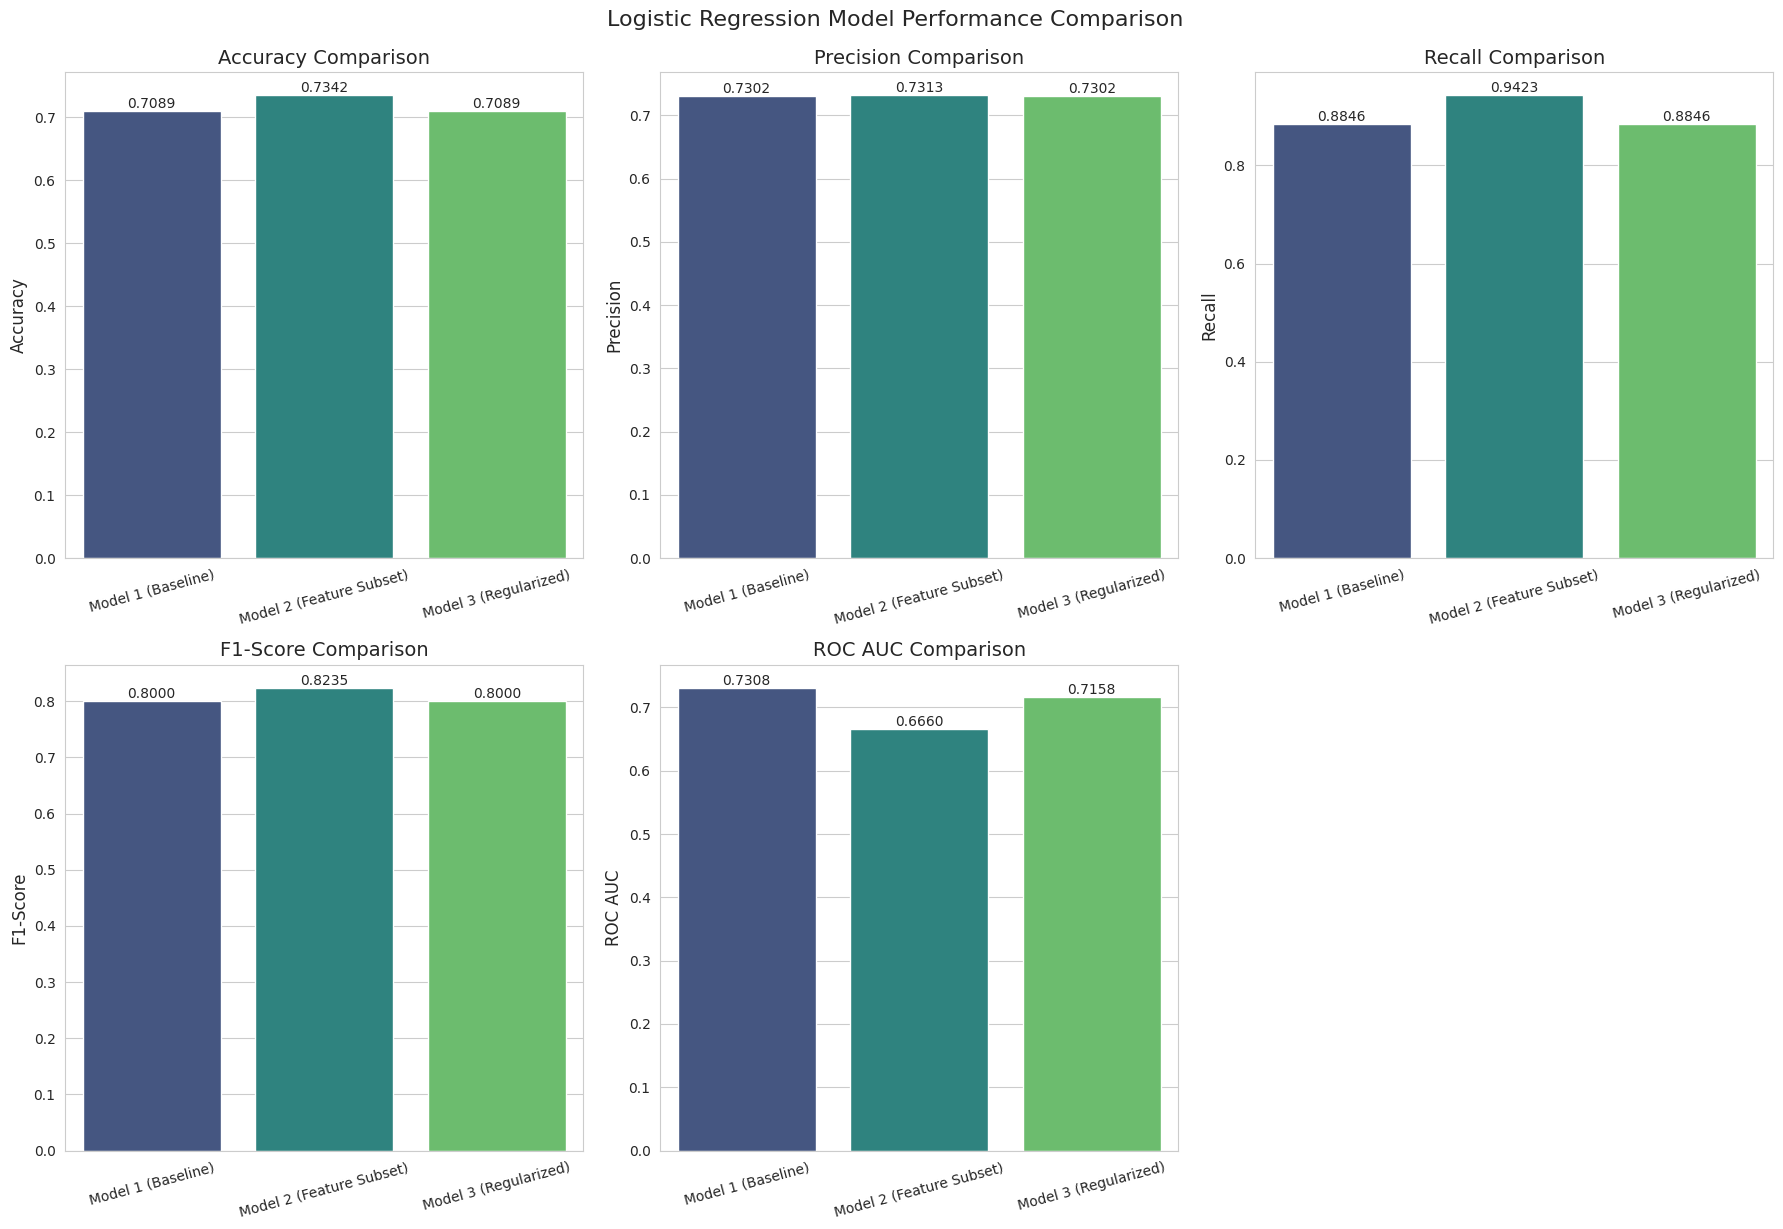

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Collected metrics (from previous output)
metrics = {
    'Model': ['Model 1 (Baseline)', 'Model 2 (Feature Subset)', 'Model 3 (Regularized)'],
    'Accuracy': [0.7089, 0.7342, 0.7089],
    'Precision': [0.7302, 0.7313, 0.7302],
    'Recall': [0.8846, 0.9423, 0.8846],
    'F1-Score': [0.8000, 0.8235, 0.8000],
    'ROC AUC': [0.7308, 0.6660, 0.7158]
}

metrics_df = pd.DataFrame(metrics)

# Set style for plots
sns.set_style('whitegrid')

# Plotting each metric
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_df.columns[1:]): # Skip 'Model' column
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison', fontsize=14)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

    # Add value labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f')

# Remove empty subplot if any
if len(metrics_df.columns[1:]) < len(axes):
    for j in range(len(metrics_df.columns[1:]), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Logistic Regression Model Performance Comparison', y=1.02, fontsize=16)
plt.show()
